Earliest start times: {'A': 0, 'B': 3, 'C': 3, 'D': 5, 'E': 7, 'F': 10}
Earliest finish times: {'A': 3, 'B': 5, 'C': 7, 'D': 7, 'E': 10, 'F': 11}
Latest start times: {'F': 10, 'E': 7, 'D': 8, 'C': 3, 'B': 6, 'A': 0}
Latest finish times: {'A': 3, 'B': 8, 'C': 7, 'D': 10, 'E': 10, 'F': 11}
Critical path: ['A', 'C', 'E', 'F']


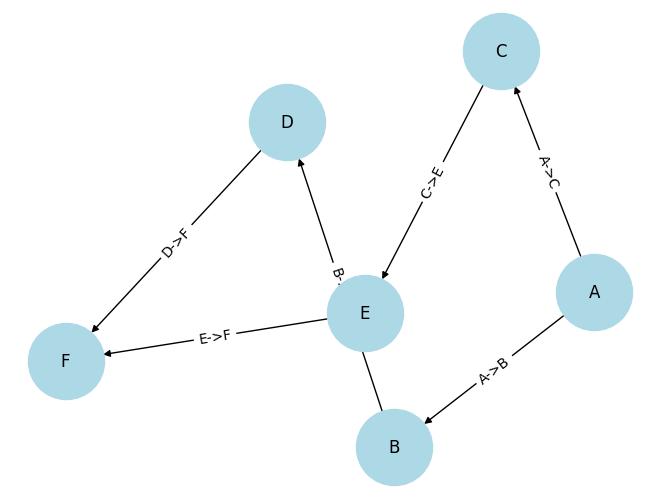

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

tasks = {
    'A': {'duration': 3, 'dependencies': []},
    'B': {'duration': 2, 'dependencies': ['A']},
    'C': {'duration': 4, 'dependencies': ['A']},
    'D': {'duration': 2, 'dependencies': ['B']},
    'E': {'duration': 3, 'dependencies': ['C']},
    'F': {'duration': 1, 'dependencies': ['D', 'E']}
}

G = nx.DiGraph()

for task, data in tasks.items():
    G.add_node(task, duration=data['duration'])
    for dep in data['dependencies']:
        G.add_edge(dep, task)

order = list(nx.topological_sort(G))

# Forward pass
ES = {t: 0 for t in order}
EF = {}

for t in order:
    EF[t] = ES[t] + G.nodes[t]['duration']
    for s in G.successors(t):
        ES[s] = max(ES[s], EF[t])

# Backward pass (FIXED)
project_duration = max(EF.values())

LF = {t: project_duration for t in order}
LS = {}

for t in reversed(order):
    LS[t] = LF[t] - G.nodes[t]['duration']
    for p in G.predecessors(t):
        LF[p] = min(LF[p], LS[t])

# Critical path
critical_path = [t for t in order if ES[t] == LS[t]]

print("Earliest start times:", ES)
print("Earliest finish times:", EF)
print("Latest start times:", LS)
print("Latest finish times:", LF)
print("Critical path:", critical_path)

# Plot
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=3000, node_color='lightblue')
labels=nx.get_node_attributes(G,'duration')
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): f"{u}->{v}" for u, v in G.edges})
plt.show()